**Imports and Model Setup**

In [1]:
import torch

print("PyTorch version:", torch.__version__)  # Should show CUDA version
print("CUDA version in PyTorch:", torch.version.cuda)  # Should match installed CUDA (e.g., 12.1)
print("CUDA available:", torch.cuda.is_available())  # Should return True
print("Number of GPUs:", torch.cuda.device_count())  # Should be > 0
print("GPU Name:", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "No GPU detected")

PyTorch version: 2.2.0+cu118
CUDA version in PyTorch: 11.8
CUDA available: True
Number of GPUs: 1
GPU Name: NVIDIA GeForce RTX 4050 Laptop GPU


In [2]:
import numpy as np
import matplotlib.pyplot as plt
import glob
import cv2
import torch

In [5]:
from mobile_sam import sam_model_registry, SamAutomaticMaskGenerator, SamPredictor

model_type = "vit_t"
sam_checkpoint = "model/MobileSAM_Vortex_checkpoint.pth"
device = "cpu"  # set device to cpu temporarily for dataset transforms

mobile_sam = sam_model_registry[model_type](checkpoint=sam_checkpoint)
mobile_sam.to(device=device)

predictor = SamPredictor(mobile_sam)
mask_generator = SamAutomaticMaskGenerator(mobile_sam)

**Generate Dataset**

## Data

Preparing Data for training/validation (not yet test). Training and validation process using PyTorch requires two main implementations: `Dataset`, `Dataloader`.  

In [6]:
import os.path as osp
import numpy as np
import cv2
from patchify import patchify
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
from collections import namedtuple

ImageMaskPathItem = namedtuple("ImageMaskPathItem", ["image_path", "mask_path", "box_path"])

class ImageMaskDataset(Dataset):
    def __init__(self, root, image_subdir, mask_subdir, box_subdir, transform=None):
        super().__init__()
        self.root = root
        self.image_subdir = image_subdir
        self.mask_subdir = mask_subdir
        self.box_subdir = box_subdir
        self.transform = transform

        images = glob.glob(osp.join(root, image_subdir, "*.png"))
        images = sorted(images)
        masks = [image.replace(image_subdir, mask_subdir) for image in images]
        boxes = [mask.replace(mask_subdir, box_subdir).replace(".png", ".npy") for mask in masks]

        self.path_items = [ImageMaskPathItem(image_path=image, mask_path=mask, box_path=box) for image, mask, box in zip(images, masks, boxes)]
        self._sanity_check()
        print(f"Found {len(self.path_items)} image-mask pairs")

    def _sanity_check(self):
        for item in self.path_items:
            assert osp.exists(item.image_path), f"Image path {item.image_path} does not exist"
            assert osp.exists(item.mask_path), f"Mask path {item.mask_path} does not exist"
            assert osp.exists(item.box_path), f"Mask path {item.box_path} does not exist"

    def __getitem__(self, index):
        item = self.path_items[index]
        image = cv2.imread(item.image_path)
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB) #stop from retrieving as redish image
        mask = cv2.imread(item.mask_path, cv2.IMREAD_GRAYSCALE)
        box = np.load(item.box_path)
        
        if self.transform:
            transformed = self.transform(image=image, mask=mask) #normalized and permuted
            image = transformed["image"]
            mask = transformed["mask"]
            box = torch.tensor(box)

        return image, mask, box

    def __len__(self):
        return len(self.path_items)

In [ ]:
import torch
from mobile_sam.utils import transforms
from torchvision import transforms as T
import albumentations as A
from albumentations.pytorch import ToTensorV2

transform = A.Compose(
    [
        ToTensorV2(), #equivalent of permute/transpose
    ], is_check_shapes = False #disabel size match verificaiton between img and mask
)

ds = ImageMaskDataset(root="processed_data", image_subdir="images", mask_subdir="masks", box_subdir="boxes", transform=transform)
train_ds, val_ds = train_test_split(ds, test_size=0.2, random_state=42)
print(f"Train dataset size: {len(train_ds)}")
print(f"Validation dataset size: {len(val_ds)}")

print("Train dataset sample:")
print(train_ds[0][0])
print(train_ds[0][1].shape)
print(train_ds[0][2].shape)

Found 35 image-mask pairs
Train dataset size: 28
Validation dataset size: 7
Train dataset sample:
tensor([[[ 4,  4,  4,  ...,  5,  5,  5],
         [ 4,  4,  4,  ...,  5,  5,  5],
         [ 4,  4,  4,  ...,  5,  5,  5],
         ...,
         [57, 57, 57,  ...,  9,  9,  9],
         [57, 57, 57,  ...,  9,  9,  9],
         [57, 57, 57,  ...,  9,  9,  9]],

        [[16, 16, 16,  ..., 20, 20, 20],
         [16, 16, 16,  ..., 20, 20, 20],
         [16, 16, 16,  ..., 20, 20, 20],
         ...,
         [57, 57, 57,  ..., 29, 29, 29],
         [57, 57, 57,  ..., 31, 32, 32],
         [57, 57, 57,  ..., 31, 32, 32]],

        [[27, 27, 27,  ..., 33, 33, 33],
         [27, 27, 27,  ..., 33, 33, 33],
         [27, 27, 27,  ..., 33, 33, 33],
         ...,
         [57, 57, 57,  ..., 48, 49, 49],
         [57, 57, 57,  ..., 52, 54, 54],
         [57, 57, 57,  ..., 52, 54, 54]]], dtype=torch.uint8)
torch.Size([256, 256])
torch.Size([1, 4])


In [11]:
BATCH_SIZE = 8
NUM_WORKERS = 4

train_dl = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, num_workers=NUM_WORKERS)
val_dl = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS)

**Dataset Processor for MobileSAM**

In [14]:
from mobile_sam import sam_model_registry, SamPredictor

model_type = "vit_t"
sam_checkpoint = "model/MobileSAM_Vortex_checkpoint.pth"
device = "cuda" if torch.cuda.is_available() else "cpu"

mobile_sam = sam_model_registry["vit_t"](checkpoint=sam_checkpoint)
mobile_sam.to(device=device)
predictor = SamPredictor(mobile_sam)

In [15]:
# Freeze layers in MobileSAM
for name, param in mobile_sam.named_parameters():
    if name.startswith("image_encoder"):  # Assuming "image_encoder" corresponds to the vision encoder
        param.requires_grad = False  # Freeze the vision encoder
    elif name.startswith("prompt_encoder"):  # Assuming "prompt_encoder" exists in MobileSAM
        param.requires_grad = False  # Freeze the prompt encoder

# Verify trainable parameters
trainable_params = sum(p.numel() for p in mobile_sam.parameters() if p.requires_grad)
print(f"Trainable parameters: {trainable_params}")

# Iterate through all parameters and check their trainable status
print("MobileSAM Parameters:")
for name, param in mobile_sam.named_parameters():
    print(f"{name}: {'Trainable' if param.requires_grad else 'Frozen'}")

# Count the total trainable parameters
trainable_params = sum(p.numel() for p in mobile_sam.parameters() if p.requires_grad)
print(f"\nTotal Trainable Parameters in MobileSAM: {trainable_params}")

Trainable parameters: 4058340
MobileSAM Parameters:
image_encoder.patch_embed.seq.0.c.weight: Frozen
image_encoder.patch_embed.seq.0.bn.weight: Frozen
image_encoder.patch_embed.seq.0.bn.bias: Frozen
image_encoder.patch_embed.seq.2.c.weight: Frozen
image_encoder.patch_embed.seq.2.bn.weight: Frozen
image_encoder.patch_embed.seq.2.bn.bias: Frozen
image_encoder.layers.0.blocks.0.conv1.c.weight: Frozen
image_encoder.layers.0.blocks.0.conv1.bn.weight: Frozen
image_encoder.layers.0.blocks.0.conv1.bn.bias: Frozen
image_encoder.layers.0.blocks.0.conv2.c.weight: Frozen
image_encoder.layers.0.blocks.0.conv2.bn.weight: Frozen
image_encoder.layers.0.blocks.0.conv2.bn.bias: Frozen
image_encoder.layers.0.blocks.0.conv3.c.weight: Frozen
image_encoder.layers.0.blocks.0.conv3.bn.weight: Frozen
image_encoder.layers.0.blocks.0.conv3.bn.bias: Frozen
image_encoder.layers.0.blocks.1.conv1.c.weight: Frozen
image_encoder.layers.0.blocks.1.conv1.bn.weight: Frozen
image_encoder.layers.0.blocks.1.conv1.bn.bias: F

**Training Loop**

In [16]:
from torch.optim import Adam
from torch.optim.lr_scheduler import ReduceLROnPlateau

# Initialize the optimizer for the mask decoder
optimizer = Adam(mobile_sam.mask_decoder.parameters(), lr=1e-3, weight_decay=0)

from torch import nn
from torch.nn import functional as F

class DiceBCELoss(nn.Module):
    def __init__(self, weight=None, size_average=True):
        super(DiceBCELoss, self).__init__()

    def forward(self, inputs, targets, smooth=1):

        # comment out if your model contains a sigmoid or equivalent activation layer
        inputs = F.sigmoid(inputs)

        # flatten label and prediction tensors
        inputs = inputs.view(-1)
        targets = targets.view(-1)

        intersection = (inputs * targets).sum()
        dice_loss = 1 - (2.0 * intersection + smooth) / (inputs.sum() + targets.sum() + smooth)
        BCE = F.binary_cross_entropy(inputs, targets, reduction="mean")
        Dice_BCE = BCE + dice_loss

        return Dice_BCE

#define loss and scheduler
seg_loss = DiceBCELoss()
scheduler = ReduceLROnPlateau(optimizer, mode="min", factor=0.1, patience=3, verbose=True)

c:\Users\juhye\AppData\Local\Programs\Python\Python312\Lib\site-packages\torch\optim\lr_scheduler.py:28: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn("The verbose parameter is deprecated. Please use get_last_lr() "


In [17]:
from tqdm import tqdm
from statistics import mean
import torch

# Training loop
num_epochs = 1
device = "cuda" if torch.cuda.is_available() else "cpu"
mobile_sam.to(device)

mobile_sam.train()
for epoch in range(num_epochs):
    train_losses = []
    for batch in tqdm(train_dl, desc=f"Epoch {epoch+1}/{num_epochs} - Training"):
        # data type adjustment for "mobilesam"
        images, masks, box = batch
        images = images.to(device) # (3, W, H), float32
        masks = (masks / 255).round().float().to(device) # (W, H), float32
        box = (box).round().float().to(device) # (4), float32
    
        batched_input = [{"image": images[idx], "original_size": (256, 256), "boxes" : box[idx].unsqueeze(0), "mask_inputs" : masks[idx].unsqueeze(0)} for idx in range(len(images))]  
        outputs = mobile_sam(batched_input=batched_input, multimask_output=False)  # requires the whole batch
        predicted_masks = torch.stack([output["masks"].squeeze(1).float() for output in outputs])

        # loss calculation/optimization
        train_loss = seg_loss(predicted_masks, masks)
        train_losses.append(train_loss.item())
        optimizer.zero_grad()
        train_loss.backward()
        optimizer.step()

        if (len(train_losses)) % 100 == 0:
            print(f"Batch {len(train_losses)+1}/{len(train_dl)} - Training Loss: {train_loss.item():.2f}")

    mean_train_loss = mean(train_losses)
    train_losses.clear()

    # Validation loss calculation
    mobile_sam.eval()
    val_losses = []
    with torch.no_grad():
        for batch in tqdm(val_dl, desc=f"Epoch {epoch+1}/{num_epochs} - Validation"):
            images, masks, box = batch
            images = images.to(device) # (3, W, H), float32
            masks = (masks / 255).round().float().to(device) # (W, H), float32
            box = (box / 255).round().float().to(device) # (4), float32

            batched_input = [{"image": images[idx], "original_size": (256, 256), "boxes" : box[idx].unsqueeze(0), "mask_inputs" : masks[idx].unsqueeze(0)} for idx in range(len(images))]  
            outputs = mobile_sam(batched_input=batched_input, multimask_output=False)
            predicted_masks = torch.stack([output["masks"].squeeze(1).float() for output in outputs])

            val_loss = seg_loss(predicted_masks, masks)
            val_losses.append(val_loss.item())

    mean_val_loss = mean(val_losses)

    print(f"EPOCH: {epoch + 1}/{num_epochs} - Train Loss: {mean_train_loss:.4f} | Val Loss: {mean_val_loss:.4f}")
    scheduler.step(val_loss)
    mobile_sam.train()

Epoch 1/1 - Validation: 100%|██████████| 1/1 [00:02<00:00,  2.72s/it]

EPOCH: 1/1 - Train Loss: 1.2047 | Val Loss: 1.4963


In [149]:
# Save the state_dict after moving layers
torch.save(mobile_sam.state_dict(), "model/MobileSAM_Vortex_checkpoint.pth")

## Inference

In [150]:
from mobile_sam import sam_model_registry, SamPredictor

vortex_model = sam_model_registry["vit_t"](checkpoint="model/MobileSAM_Vortex_checkpoint.pth")
vortex_model.eval()
predictor = SamPredictor(vortex_model)

c:\Users\user\Documents\slurry_viscnet\MobileSAM_Vortex\mobile_sam\build_sam.py:91: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  state_dict = torch.load(f)


[[-240.20677 -320.63727 -284.66077 ... -230.47575 -227.10857 -287.22302]
 [-344.19427 -376.14893 -326.1001  ... -283.3109  -259.57175 -301.71976]
 [-278.45676 -419.38367 -283.56427 ... -377.7967  -228.23546 -246.2782 ]
 ...
 [-153.40509 -264.0299  -353.1317  ... -428.38104 -321.60437 -320.2169 ]
 [-338.6194  -446.42984 -320.7867  ... -427.72864 -334.7216  -379.20886]
 [-377.97864 -408.0373  -239.21188 ... -419.68732 -278.04178 -317.58398]]
[[ 16 192 228 ...  26  29 225]
 [168 136 186 ... 229 253 211]
 [234  93 229 ... 135  28  10]
 ...
 [103 248 159 ...  84 191 192]
 [174  66 192 ...  85 178 133]
 [135 104  17 ...  93 234 195]]


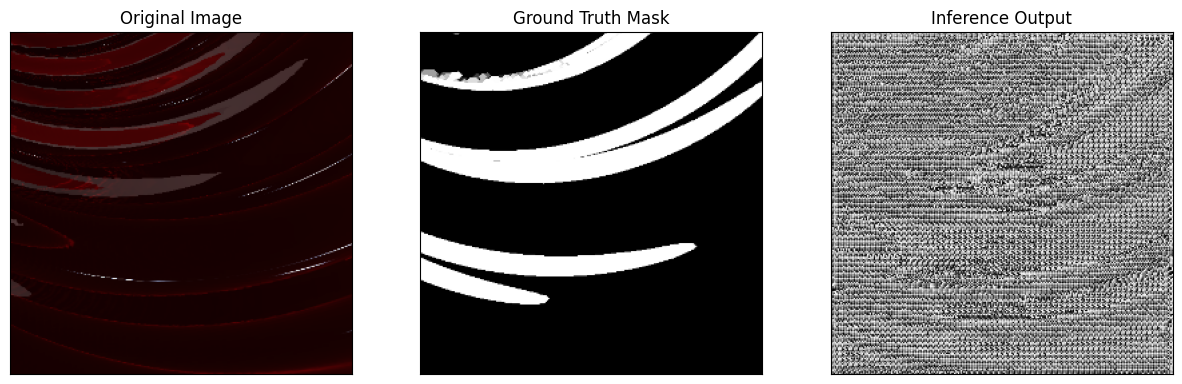

[[-173.99892  -238.97278  -227.57724  ... -207.90729  -185.56775
  -224.91745 ]
 [-261.11862  -300.8188   -283.99786  ... -271.56934  -219.64746
  -256.40582 ]
 [-163.38162  -266.95337  -227.44385  ... -293.24335  -212.47687
  -215.52495 ]
 ...
 [-282.45422  -326.65204  -252.17828  ...   22.357964 -118.06631
  -110.33758 ]
 [-275.27313  -336.58066  -241.62477  ... -183.3485   -136.60617
  -192.74847 ]
 [-338.31796  -354.0715   -215.18633  ... -182.46185   -97.33376
   -76.77455 ]]
[[ 83  18  29 ...  49  71  32]
 [251 212 229 ... 241  37   0]
 [ 93 246  29 ... 219  44  41]
 ...
 [230 186   4 ...  22 138 146]
 [237 176  15 ...  73 120  64]
 [174 158  41 ...  74 159 180]]


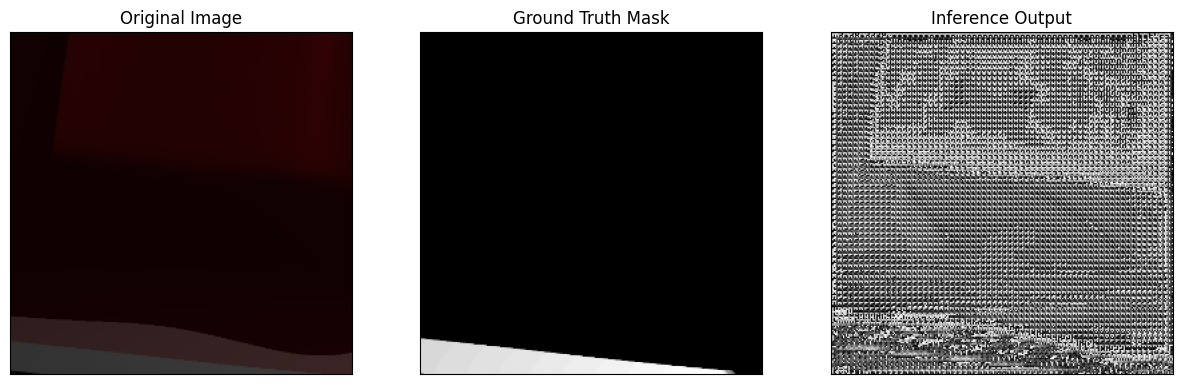

[[-181.88564 -237.5972  -215.87515 ... -192.4253  -167.39743 -209.12238]
 [-287.50623 -307.9814  -244.14131 ... -242.15512 -186.74019 -225.6975 ]
 [-216.4251  -310.4045  -235.2142  ... -287.4912  -180.95157 -191.03418]
 ...
 [-265.14642 -325.96692 -251.10623 ... -271.364   -238.60828 -244.99872]
 [-287.92273 -375.31293 -244.10158 ... -315.97925 -244.79114 -290.87115]
 [-360.3757  -406.00116 -289.19113 ... -311.40857 -197.50146 -233.85936]]
[[ 75  19  41 ...  64  89  47]
 [225 205  12 ...  14  70  31]
 [ 40 202  21 ... 225  76  65]
 ...
 [247 187   5 ... 241  18  12]
 [225 137  12 ... 197  12 222]
 [152 106 223 ... 201  59  23]]


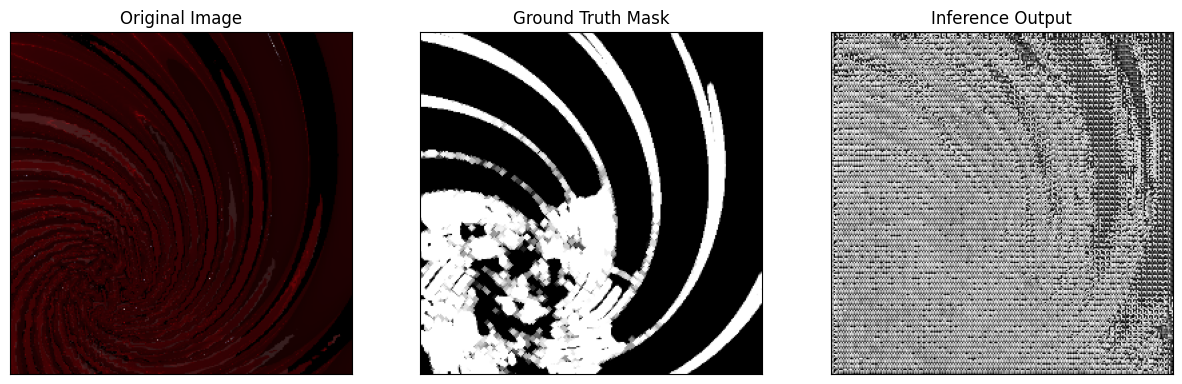

[[-155.59937 -201.7987  -176.14389 ... -158.7167  -140.27689 -173.2585 ]
 [-231.67142 -263.94666 -198.48106 ... -195.12947 -165.77243 -190.34933]
 [-174.65002 -252.14627 -179.71967 ... -234.9564  -153.14949 -165.67493]
 ...
 [-136.68558 -200.65753 -186.48102 ...  -77.65471 -159.36902 -166.86212]
 [-204.3538  -287.2718  -174.8536  ... -232.45975 -241.38293 -321.022  ]
 [-241.13792 -283.75616 -170.68939 ... -196.2083  -283.33942 -293.00256]]
[[101  55  80 ...  98 116  83]
 [ 25 249  58 ...  61  91  66]
 [ 82   4  77 ...  22 103  91]
 ...
 [120  56  70 ... 179  97  90]
 [ 52 225  82 ...  24  15 191]
 [ 15 229  86 ...  60 229 219]]


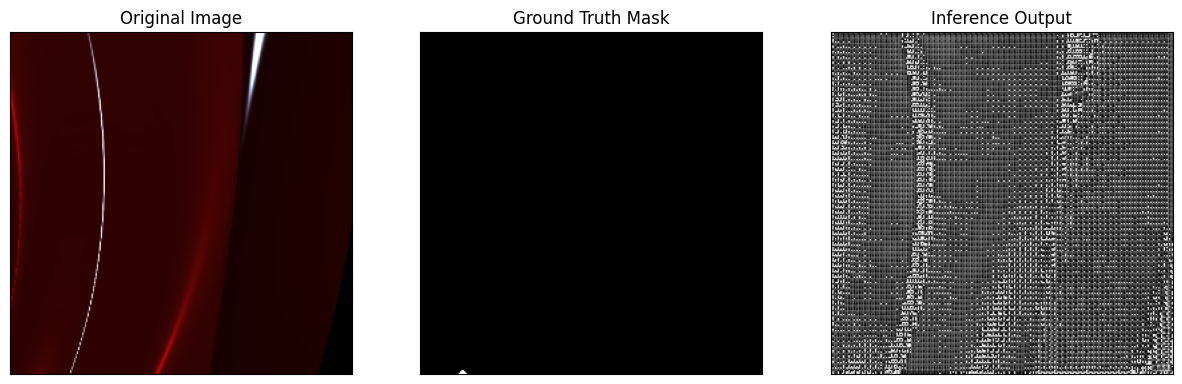

In [ ]:
import random

idx = random.randint(0, len(val_ds))
for batch in val_dl:
    images, masks, box = batch # batch_size 8
    images = images.cpu().numpy()
    masks = masks.cpu().numpy()
    box = box.cpu().numpy()

    for idx in range(len(images)-4) :
        test_image = np.transpose(images[idx], (1,2,0))
        test_mask = masks[idx]
        test_box = box[idx]

        predictor.set_image(test_image) # (H, W, C) uint8
        pred_masks, _, _ = predictor.predict(box=test_box, return_logits=True, multimask_output=False) # (1,256,256) #alter the threshold through sam.py
        pred_masks = pred_masks.squeeze(0)
        print(pred_masks) 
        pred_masks = pred_masks.astype(np.uint8)
        print(pred_masks)

        fig, axes = plt.subplots(1, 3, figsize=(15, 5))

        axes[0].imshow(test_image)
        axes[0].set_title("Original Image")

        axes[1].imshow(test_mask, cmap="gray")
        axes[1].set_title("Ground Truth Mask")

        axes[2].imshow(pred_masks, cmap="gray")
        axes[2].set_title("Inference Output")

        for ax in axes:
            ax.set_xticks([])
            ax.set_yticks([])
            ax.set_xticklabels([])
            ax.set_yticklabels([])
            
        plt.show()

    break #only one batch iterations
    

In [ ]:
torch.cuda.empty_cache()